# Two-qubit randomized compiling + cycle benchmarking + QCAP

## True-Q analysis with Hashim et al. Table II normalization

This notebook is a clean replacement for the earlier pooled-Pauli CB analysis.

The methodological contract is:

1. CB uses a **Pauli twirl**, so the effective error channel is Pauli stochastic, not automatically globally depolarizing.
2. At fixed Pauli `P` and sequence length `m`, average only over independent randomized CB circuit realizations.
3. Fit each Pauli decay separately,
   $$S_P(m) = A_P p_P^m.$$
4. For two qubits, retain all 15 nonidentity fitted `p_P` values and set `p_II = 1` exactly.
5. Form the CB process-fidelity estimator in the same form used by the CB review and True-Q output,
   $$F_e^{\rm CB} = \frac{1}{d^2}\sum_{P\in\mathcal P_n}p_P
   = \frac{1+\sum_{P\ne I}p_P}{d^2}.$$
6. Only then use Table II to convert between process fidelity, process infidelity, process polarization, and average gate infidelity:
   $$e_F = 1-F_e,$$
   $$f = \frac{d^2F_e-1}{d^2-1},$$
   $$e_F = \frac{d^2-1}{d^2}(1-f),$$
   $$r = \frac{d}{d+1}e_F.$$

The individual `p_P` values are never overwritten by the scalar `f`. Computing the scalar is a trace/summary operation, not a replacement of the physical Pauli channel by a depolarizing channel.

For a nontrivial Clifford cycle, a CB decay can be an orbital/geometric-mean quantity rather than one individually identifiable PTM eigenvalue. For CZ, the target has order two; using even depths follows the standard CB construction and the PARRILLA notebook.


In [40]:
# Colab setup. Comment this cell out if the packages are already installed.
%pip -q install qiskit qiskit-aer scipy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [41]:
import math
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Clifford, Pauli, Statevector
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    ReadoutError,
    depolarizing_error,
    coherent_unitary_error,
)

SEED = 42
N_QUBITS = 2
D_HILBERT = 2 ** N_QUBITS

# Application-circuit depths.
DEPTHS = [1, 2, 4, 8, 16, 32, 64, 128]
N_CIRC_PER_DEPTH = 40
ENTROPY_DEPTH = 16

# Randomized compiling for the application circuits.
N_RC = 30
SHOTS_PER_RC = 512

# PARRILLA uses [4, 16, 32, 64, 128] for CZ CB. All are even, as CZ^2 = I.
CB_DEPTHS = [4, 16, 32, 64, 128]
CB_N_RC = 20       # independent randomized circuits per (P, m)
CB_SHOTS = 4096    # shots per randomized circuit

# Application-circuit one-qubit gates. These are NOT averaged into the CB Pauli decay.
ONEQ_SETS = {
    "random": ["h", "s", "sdg", "x", "y", "z", "sx", "sxdg", "t"],
    "structured": ["i", "h", "x"],
}
MODES = ("random", "structured")

# Noise parameters carried over from the earlier notebook.
p1 = 1e-3
p2 = 1e-2
cz_overrot = 0.05
zz_angle = 0.08
p_readout = 0.02
THETA_ZZ = cz_overrot + zz_angle

BASIS_GATES = [
    "id", "x", "y", "z", "h", "s", "sdg", "sx", "sxdg",
    "t", "tdg", "rz", "u", "unitary", "cz", "measure",
]

sim = AerSimulator()


## 1. Noise model

The coherent controlled-phase error is retained before randomized compiling. Pauli randomized compiling projects this error into a Pauli-diagonal effective channel when averaged over randomizations.

The CB routine below benchmarks the **CZ target cycle with Pauli randomized compilation**, matching the PARRILLA/True-Q organization. The arbitrary application-circuit one-qubit layers are not mixed into the Pauli-decay fit.


In [42]:
ONEQ_GATE_NAMES = [
    "id", "h", "x", "y", "z", "s", "sdg", "sx", "sxdg",
    "t", "tdg", "rz", "u", "unitary",
]


def cp_unitary(theta):
    return np.diag([1.0, 1.0, 1.0, np.exp(1j * theta)]).astype(complex)


def build_noise_model(p1=p1, p2=p2, theta_zz=THETA_ZZ, p_readout=p_readout):
    nm = NoiseModel(basis_gates=BASIS_GATES)
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ONEQ_GATE_NAMES)

    cz_err = coherent_unitary_error(cp_unitary(theta_zz)).compose(
        depolarizing_error(p2, 2)
    )
    nm.add_all_qubit_quantum_error(cz_err, ["cz"])

    nm.add_all_qubit_readout_error(
        ReadoutError([[1 - p_readout, p_readout], [p_readout, 1 - p_readout]])
    )
    return nm


noise_model = build_noise_model()
print("noise model ready")
print("theta_ZZ =", THETA_ZZ)


noise model ready
theta_ZZ = 0.13


## 2. Readout calibration

Readout enters QCAP separately from the CB decay fits. This follows the PARRILLA notebook's separation of readout fidelity from cycle process infidelity.


In [43]:
def readout_confusion_fidelity(noise_model, shots=8192, seed=SEED):
    n_states = 2 ** N_QUBITS
    circs = []
    for prep in range(n_states):
        qc = QuantumCircuit(N_QUBITS)
        for q in range(N_QUBITS):
            if (prep >> q) & 1:
                qc.x(q)
        qc.measure_all()
        circs.append(qc)

    circs = transpile(circs, sim, optimization_level=0)
    results = sim.run(
        circs,
        noise_model=noise_model,
        shots=shots,
        seed_simulator=seed,
    ).result()

    C = np.zeros((n_states, n_states), dtype=float)
    for prep in range(n_states):
        for bs, count in results.get_counts(prep).items():
            b = bs.replace(" ", "")[::-1]
            idx = sum(int(b[q]) << q for q in range(N_QUBITS))
            C[prep, idx] += count
    C /= C.sum(axis=1, keepdims=True)
    diag = np.diag(C)
    return float(np.mean(diag)), float(np.std(diag)), C


ro_fid, ro_std, confusion = readout_confusion_fidelity(noise_model)
print(f"readout fidelity = {ro_fid:.6f} +/- {ro_std:.6f}")
print("confusion diagonal =", np.round(np.diag(confusion), 6))


readout fidelity = 0.960846 +/- 0.000903
confusion diagonal = [0.960693 0.961914 0.959473 0.961304]


## 3. Pauli randomized compiling helpers

The random Pauli frame is merged into a single one-qubit instruction per qubit and layer, so the randomization does not artificially increase the one-qubit instruction count. This is the same pulse-count-preserving idea used in the earlier notebook.


In [44]:
_PAULI_1Q = ("I", "X", "Y", "Z")
_PAULIS_2Q = tuple(a + b for a in _PAULI_1Q for b in _PAULI_1Q)
_PAULIS_2Q_NONID = tuple(P for P in _PAULIS_2Q if P != "II")

_SQRT_X = 0.5 * np.array(
    [[1 + 1j, 1 - 1j], [1 - 1j, 1 + 1j]], dtype=complex
)
_MAT = {
    "i": np.eye(2, dtype=complex),
    "I": np.eye(2, dtype=complex),
    "x": np.array([[0, 1], [1, 0]], dtype=complex),
    "y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "z": np.array([[1, 0], [0, -1]], dtype=complex),
    "h": np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2),
    "s": np.array([[1, 0], [0, 1j]], dtype=complex),
    "sdg": np.array([[1, 0], [0, -1j]], dtype=complex),
    "sx": _SQRT_X,
    "sxdg": _SQRT_X.conj().T,
    "t": np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex),
}
_MAT["X"], _MAT["Y"], _MAT["Z"] = _MAT["x"], _MAT["y"], _MAT["z"]


def _pauli_label(p):
    # Our labels are q0-first; qiskit Pauli labels are reversed.
    return "".join("IZXY"[int(p.x[q]) * 2 + int(p.z[q])] for q in range(len(p.z)))


def _build_cz_conjugation_table():
    qc = QuantumCircuit(2)
    qc.cz(0, 1)
    cl = Clifford(qc)
    table = {}
    for P in _PAULIS_2Q:
        table[P] = _pauli_label(Pauli(P[::-1]).evolve(cl))
    return table


CZ_CONJ = _build_cz_conjugation_table()
_MERGED_CACHE = {}


def _dephase(mat):
    flat = mat.reshape(-1)
    k = int(np.argmax(np.abs(flat) > 1e-12))
    return mat * np.exp(-1j * np.angle(flat[k]))


def merged_gate(p_after_prev, gate_name, p_this):
    key = (p_after_prev, gate_name, p_this)
    gate = _MERGED_CACHE.get(key)
    if gate is None:
        mat = _dephase(_MAT[p_this] @ _MAT[gate_name] @ _MAT[p_after_prev])
        gate = UnitaryGate(mat)
        _MERGED_CACHE[key] = gate
    return gate


def build_rc_brickwork(layers, rng=None, measure=True):
    """Application circuit: depth repetitions of [1q layer, CZ] plus trailing 1q layer."""
    qc = QuantumCircuit(N_QUBITS)
    n_cycles = len(layers) - 1
    carry = ["I"] * N_QUBITS

    for j, layer in enumerate(layers):
        twirl = rng is not None and j < n_cycles
        pre = list(_PAULIS_2Q[rng.integers(len(_PAULIS_2Q))]) if twirl else ["I"] * N_QUBITS

        for q in range(N_QUBITS):
            qc.append(merged_gate(carry[q], layer[q], pre[q]), [q])

        if j < n_cycles:
            qc.cz(0, 1)
            carry = list(CZ_CONJ["".join(pre)]) if twirl else ["I"] * N_QUBITS

    if measure:
        qc.measure_all()
    return qc


## 4. Metrics and application-circuit RC averaging


In [45]:
def make_layers(mode, depth, seed):
    rng = np.random.default_rng(seed)
    gates = ONEQ_SETS[mode]
    return [
        [gates[rng.integers(len(gates))] for _ in range(N_QUBITS)]
        for _ in range(depth + 1)
    ]


def ideal_probs(layers):
    qc = build_rc_brickwork(layers, rng=None, measure=False)
    return Statevector.from_instruction(qc).probabilities_dict()


def rc_averaged_distribution(layers, noise_model, seed, n_rc=N_RC, shots_per_rc=SHOTS_PER_RC):
    rng = np.random.default_rng(seed)
    circs = [build_rc_brickwork(layers, rng=rng, measure=True) for _ in range(n_rc)]
    circs = transpile(circs, sim, optimization_level=0)
    result = sim.run(
        circs,
        noise_model=noise_model,
        shots=shots_per_rc,
        seed_simulator=int(seed) % (2 ** 31),
    ).result()

    total = {}
    for i in range(n_rc):
        for bitstring, count in result.get_counts(i).items():
            total[bitstring] = total.get(bitstring, 0) + count
    norm = sum(total.values())
    return {k: v / norm for k, v in total.items()}


def total_variation_distance(p, q):
    keys = set(p) | set(q)
    return 0.5 * sum(abs(p.get(k, 0.0) - q.get(k, 0.0)) for k in keys)


def classical_fidelity(p, q):
    keys = set(p) | set(q)
    return sum(math.sqrt(p.get(k, 0.0) * q.get(k, 0.0)) for k in keys) ** 2


def shannon_entropy(dist):
    return -sum(prob * math.log2(prob) for prob in dist.values() if prob > 0)


## 5. PARRILLA/True-Q-style cycle benchmarking

This is the central correction.

At fixed `(P, m)` we average over randomized CB circuits. We do **not** pool different Pauli labels before fitting. Each nonidentity Pauli gets its own fitted `p_P`.

The target cycle is CZ. Each CZ is randomized with a fresh Pauli frame. The base one-qubit operation in the CB cycle is the identity, so the arbitrary application-circuit single-qubit gates are not sampled inside CB.

For even `m`, `CZ^m = I`, which is the standard construction used by the review and is consistent with the PARRILLA depth choices.


In [46]:
def prep_random_eigenstate(qc, letters, rng):
    """Prepare a random tensor-product eigenstate of P and return its P eigenvalue."""
    total_sign = 1.0
    for q, ch in enumerate(letters):
        local_sign = 1 if rng.integers(2) == 0 else -1

        if ch == "I":
            # Identity has no preferred eigenbasis. Randomize a computational state
            # to avoid fixing the spectator qubit to one state in every circuit.
            if local_sign < 0:
                qc.x(q)
            continue

        total_sign *= local_sign
        if ch == "X":
            if local_sign < 0:
                qc.x(q)
            qc.h(q)
        elif ch == "Y":
            qc.h(q)
            if local_sign > 0:
                qc.s(q)
            else:
                qc.sdg(q)
        elif ch == "Z":
            if local_sign < 0:
                qc.x(q)
        else:
            raise ValueError(f"Unknown Pauli letter: {ch}")

    return total_sign


def measure_rotation(qc, letters):
    """Rotate the requested Pauli observable to the computational basis."""
    for q, ch in enumerate(letters):
        if ch == "X":
            qc.h(q)
        elif ch == "Y":
            qc.sdg(q)
            qc.h(q)


def target_pauli_image(P, m):
    """Return (letters, sign) for CZ^m P CZ^{-m}."""
    qc = QuantumCircuit(N_QUBITS)
    for _ in range(m):
        qc.cz(0, 1)
    out = Pauli(P[::-1]).evolve(Clifford(qc), frame="s")
    return _pauli_label(out), float(np.real((-1j) ** out.phase))


def pauli_ev_from_counts(counts, letters, sign=1.0):
    support = [q for q, ch in enumerate(letters) if ch != "I"]
    if not support:
        return 1.0

    total = 0
    accum = 0.0
    for bitstring, count in counts.items():
        b = bitstring.replace(" ", "")[::-1]
        parity = sum(int(b[q]) for q in support) % 2
        accum += count * (1.0 if parity == 0 else -1.0)
        total += count
    return float(sign * accum / total)


def mean_sd_sem(values):
    arr = np.asarray(values, dtype=float)
    sd = float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    sem = sd / math.sqrt(arr.size) if arr.size else 0.0
    return float(arr.mean()), sd, sem


def fit_decay(m, y, sigma=None):
    """Fit y = A p^m and return A, p, std_A, std_p."""
    m = np.asarray(m, dtype=float)
    y = np.asarray(y, dtype=float)

    def model(x, A, p):
        return A * p ** x

    kwargs = {}
    if sigma is not None:
        kwargs = {
            "sigma": np.maximum(np.asarray(sigma, dtype=float), 1e-6),
            "absolute_sigma": True,
        }

    popt, pcov = curve_fit(
        model,
        m,
        y,
        p0=[min(max(float(y[0]), 0.5), 1.05), 0.99],
        bounds=([0.0, 0.0], [1.2, 1.0]),
        maxfev=20000,
        **kwargs,
    )
    std = np.sqrt(np.maximum(np.diag(pcov), 0.0))
    return float(popt[0]), float(popt[1]), float(std[0]), float(std[1])


def build_cb_circuit(P, m, rng):
    """One independent randomized CB circuit for target cycle CZ."""
    if m % 2:
        raise ValueError("For CZ CB in this PARRILLA-like construction, use even m so CZ^m = I.")

    # Identity base layers: the only 1q content in CB is the randomized Pauli frame.
    layers = [["i"] * N_QUBITS for _ in range(m + 1)]
    measured_letters, ideal_sign = target_pauli_image(P, m)

    qc = QuantumCircuit(N_QUBITS)
    prep_sign = prep_random_eigenstate(qc, P, rng)
    qc.compose(build_rc_brickwork(layers, rng=rng, measure=False), inplace=True)
    measure_rotation(qc, measured_letters)
    qc.measure_all()

    # In the noiseless circuit, the phaseless measured Pauli has expectation
    # ideal_sign * prep_sign. Multiplying by the same +/-1 makes the survival +1.
    correction_sign = ideal_sign * prep_sign
    return qc, measured_letters, correction_sign


def cycle_benchmark_trueq(
    noise_model,
    depths=CB_DEPTHS,
    n_rc=CB_N_RC,
    shots=CB_SHOTS,
    seed=SEED,
):
    """Pauli-resolved CB, followed by PARRILLA/True-Q and Table-II aggregation."""
    if any(m % 2 for m in depths):
        raise ValueError("All CZ CB depths must be even in this construction.")

    rng = np.random.default_rng(seed)
    per_pauli = {P: [] for P in _PAULIS_2Q_NONID}

    # At each depth, every P gets its own ensemble of randomized circuits.
    for m in depths:
        circuits = []
        metadata = []

        for P in _PAULIS_2Q_NONID:
            for _ in range(n_rc):
                qc, measured_letters, ideal_sign = build_cb_circuit(P, m, rng)
                circuits.append(qc)
                metadata.append((P, measured_letters, ideal_sign))

        circuits = transpile(circuits, sim, optimization_level=0)
        result = sim.run(
            circuits,
            noise_model=noise_model,
            shots=shots,
            seed_simulator=int(rng.integers(1 << 31)),
        ).result()

        by_p = {P: [] for P in _PAULIS_2Q_NONID}
        for i, (P, measured_letters, ideal_sign) in enumerate(metadata):
            value = pauli_ev_from_counts(
                result.get_counts(i), measured_letters, ideal_sign
            )
            by_p[P].append(value)

        for P in _PAULIS_2Q_NONID:
            per_pauli[P].append(mean_sd_sem(by_p[P]))

    m_arr = np.asarray(depths, dtype=float)
    pauli_fits = {}

    for P, rows in per_pauli.items():
        means = np.asarray([row[0] for row in rows], dtype=float)
        sems = np.asarray([row[2] for row in rows], dtype=float)
        A_P, p_P, A_P_std, p_P_std = fit_decay(m_arr, means, sigma=sems)
        pauli_fits[P] = {
            "A": A_P,
            "A_std": A_P_std,
            "p": p_P,
            "p_std": p_P_std,
            "means": means,
            "sems": sems,
        }

    # PARRILLA/True-Q-style aggregation: include p_II = 1 exactly.
    p_nonid = np.asarray([pauli_fits[P]["p"] for P in _PAULIS_2Q_NONID], dtype=float)
    p_nonid_std = np.asarray(
        [pauli_fits[P]["p_std"] for P in _PAULIS_2Q_NONID], dtype=float
    )

    d = float(D_HILBERT)
    d2 = d ** 2

    F_e = (1.0 + p_nonid.sum()) / d2
    e_F = 1.0 - F_e

    # Independent-fit propagation. Close to the uncertainty reported by PARRILLA/True-Q;
    # if exact cross-fit covariances are available, replace this with the full covariance.
    F_e_std = float(np.sqrt(np.sum(p_nonid_std ** 2)) / d2)
    e_F_std = F_e_std

    # Hashim et al. Table II scalar process polarization.
    f_process = (d2 * F_e - 1.0) / (d2 - 1.0)
    f_process_std = d2 / (d2 - 1.0) * F_e_std

    # Equivalent Table-II expression; this assertion guards the normalization.
    e_F_from_f = (d2 - 1.0) / d2 * (1.0 - f_process)
    assert np.allclose(e_F, e_F_from_f, rtol=1e-12, atol=1e-12)

    r = d / (d + 1.0) * e_F
    F_avg = 1.0 - r

    # Diagnostic only: arithmetic mean of measured Pauli survival means at each m.
    # We deliberately do not fit this pooled curve to obtain the authoritative e_F.
    pooled_decay = np.mean(
        np.vstack([pauli_fits[P]["means"] for P in _PAULIS_2Q_NONID]), axis=0
    )

    return {
        "depths": list(depths),
        "pauli_fits": pauli_fits,
        "p_II": 1.0,
        "F_e": float(F_e),
        "F_e_std": float(F_e_std),
        "e_F": float(e_F),
        "e_F_std": float(e_F_std),
        "f": float(f_process),
        "f_std": float(f_process_std),
        "r": float(r),
        "F_avg": float(F_avg),
        "pooled_decay_diagnostic": pooled_decay,
    }


### Run CB once

This is one CB experiment containing many independent randomized circuits. It is not an outer average over repeated full CB experiments.


In [47]:
cb = cycle_benchmark_trueq(noise_model)

print(f"F_e = {cb['F_e']:.8f} +/- {cb['F_e_std']:.8f}")
print(f"e_F = {cb['e_F']:.8f} +/- {cb['e_F_std']:.8f}")
print(f"Table-II f = {cb['f']:.8f} +/- {cb['f_std']:.8f}")
print(f"r = {cb['r']:.8f}")
print(f"F_avg = {cb['F_avg']:.8f}")

print("\nPauli fits:")
print(f"{'P':>3} {'A_P':>11} {'p_P':>11} {'std(p_P)':>13}")
print(f"{'II':>3} {1.0:>11.6f} {1.0:>11.6f} {0.0:>13.6g}")
for P in _PAULIS_2Q_NONID:
    fit = cb['pauli_fits'][P]
    print(f"{P:>3} {fit['A']:>11.6f} {fit['p']:>11.6f} {fit['p_std']:>13.6g}")


F_e = 0.98616470 +/- 0.00014593
e_F = 0.01383530 +/- 0.00014593
Table-II f = 0.98524235 +/- 0.00015566
r = 0.01106824
F_avg = 0.98893176

Pauli fits:
  P         A_P         p_P      std(p_P)
 II    1.000000    1.000000             0
 IX    0.958373    0.983731   0.000833304
 IY    0.952141    0.985050   0.000570136
 IZ    0.958354    0.989094   7.20552e-05
 XI    0.949214    0.985922   0.000477811
 XX    0.913171    0.984216   0.000501542
 XY    0.916432    0.984202    0.00042913
 XZ    0.927560    0.983299   0.000927536
 YI    0.957570    0.984119   0.000948169
 YX    0.921609    0.983096   0.000574655
 YY    0.916103    0.983811   0.000532657
 YZ    0.915602    0.985087   0.000651526
 ZI    0.961496    0.988915   7.17614e-05
 ZX    0.917234    0.984986   0.000727411
 ZY    0.910648    0.984994   0.000651353
 ZZ    0.919357    0.988111   8.34812e-05


## 6. CB diagnostics

The first plot shows the separate Pauli decays and fits. The second mirrors the interpretation of the PARRILLA/True-Q output: individual `1-p_P` values plus one horizontal scalar process-infidelity value `e_F`.

Do not interpret equality of the scalar `e_F` and a particular `1-p_P` as a statement that the channel is depolarizing.


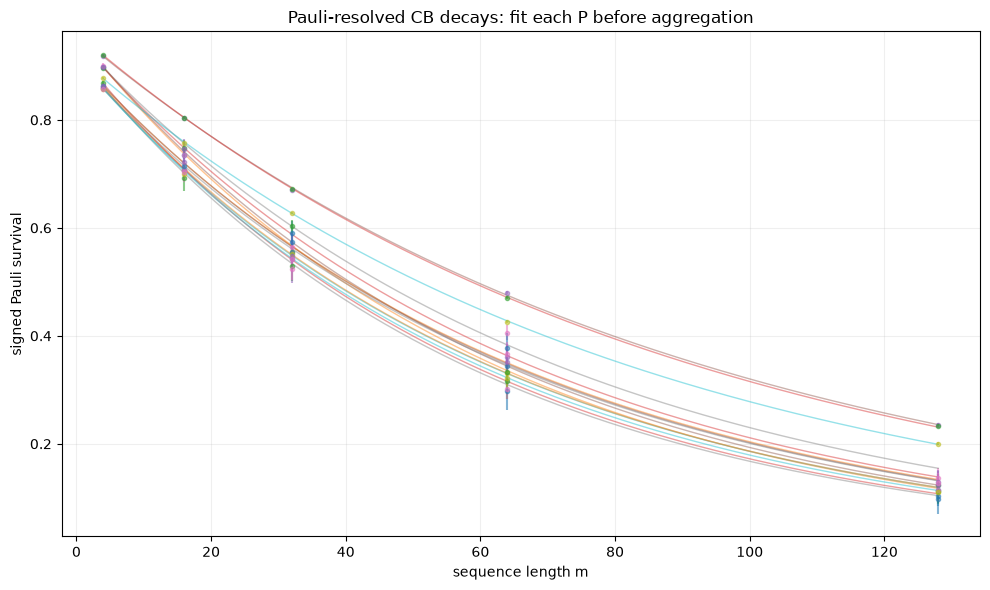

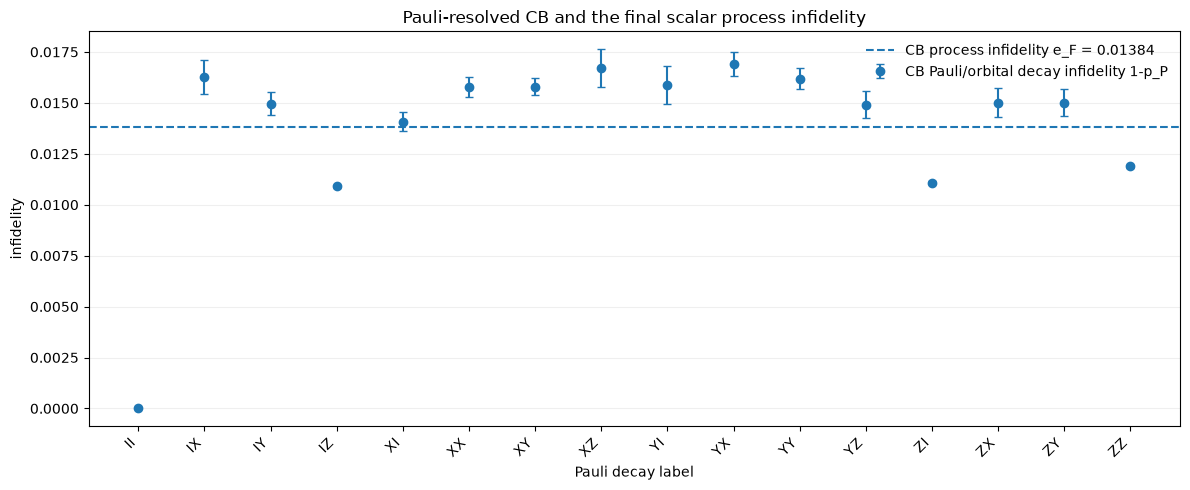

In [48]:
def plot_pauli_decays(cb):
    m = np.asarray(cb["depths"], dtype=float)
    grid = np.linspace(m.min(), m.max(), 300)
    fig, ax = plt.subplots(figsize=(10, 6))

    for P in _PAULIS_2Q_NONID:
        fit = cb["pauli_fits"][P]
        ax.errorbar(m, fit["means"], yerr=fit["sems"], fmt="o", ms=3, alpha=0.55)
        ax.plot(grid, fit["A"] * fit["p"] ** grid, lw=1, alpha=0.45)

    ax.set_xlabel("sequence length m")
    ax.set_ylabel("signed Pauli survival")
    ax.set_title("Pauli-resolved CB decays: fit each P before aggregation")
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()


def plot_pauli_infidelities(cb):
    order = ["II"] + list(_PAULIS_2Q_NONID)
    vals = [0.0] + [1.0 - cb["pauli_fits"][P]["p"] for P in _PAULIS_2Q_NONID]
    errs = [0.0] + [cb["pauli_fits"][P]["p_std"] for P in _PAULIS_2Q_NONID]

    x = np.arange(len(order))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.errorbar(x, vals, yerr=errs, fmt="o", capsize=3, label="CB Pauli/orbital decay infidelity 1-p_P")
    ax.axhline(cb["e_F"], ls="--", lw=1.5, label=f"CB process infidelity e_F = {cb['e_F']:.5f}")
    ax.set_xticks(x, order, rotation=45, ha="right")
    ax.set_ylabel("infidelity")
    ax.set_xlabel("Pauli decay label")
    ax.set_title("Pauli-resolved CB and the final scalar process infidelity")
    ax.grid(True, axis="y", alpha=0.2)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()


plot_pauli_decays(cb)
plot_pauli_infidelities(cb)


## 7. QCAP-style bound

PARRILLA's QCAP routine takes the scalar CB `e_F` and compounds the surviving process fidelity as `(1-e_F)^n`, together with readout fidelity.

The central-value calculation below follows that structure. The uncertainty propagation uses the derivative squared, i.e. ordinary first-order variance propagation.

**Important modeling caveat:** this PARRILLA-like setup marks/benchmarks the CZ cycle. If errors from arbitrary application-circuit one-qubit gates are intended to be part of the bound, they must be benchmarked as additional cycle types or explicitly folded into the definition of the benchmarked cycle. Do not silently assume that a CZ-only CB number includes unrelated one-qubit application-gate errors.


In [49]:
def qcap_bound(cycle_counts, cycle_efs, ro_fid, ro_std):
    p = float(ro_fid)
    pvar = float(ro_std) ** 2

    for cycle_key, n in cycle_counts.items():
        e_F, e_F_std = cycle_efs[cycle_key]
        y = (1.0 - e_F) ** n
        dy_de = -n * (1.0 - e_F) ** (n - 1)
        yvar = (dy_de ** 2) * (e_F_std ** 2)

        p_new = p * y
        pvar_new = y ** 2 * pvar + p ** 2 * yvar + pvar * yvar
        p, pvar = p_new, pvar_new

    return {
        "error": 1.0 - p,
        "fidelity": p,
        "std": math.sqrt(max(pvar, 0.0)),
    }


CYCLE_KEY = "CZ"
for depth in [1, 2, 4, 8, 16, 32]:
    bound = qcap_bound(
        {CYCLE_KEY: depth},
        {CYCLE_KEY: (cb["e_F"], cb["e_F_std"])},
        ro_fid,
        ro_std,
    )
    print(depth, bound)


1 {'error': 0.052447643540841304, 'fidelity': 0.9475523564591587, 'std': 0.0009012079978370243}
2 {'error': 0.06555731354602556, 'fidelity': 0.9344426864539744, 'std': 0.0009204465418050381}
4 {'error': 0.09123503434424118, 'fidelity': 0.9087649656557588, 'std': 0.0010091174586956408}
8 {'error': 0.14049305702591874, 'fidelity': 0.8595069429740813, 'std': 0.0012990137332871698}
16 {'error': 0.23114398606458064, 'fidelity': 0.7688560139354194, 'std': 0.0019584955599580836}
32 {'error': 0.3847717505111756, 'fidelity': 0.6152282494888244, 'std': 0.0029701333859247837}


## 8. Optional application-circuit comparison

This retains the earlier notebook's randomized/structured application-circuit study. It is separate from the CB estimator itself.


In [50]:
def run_mode(mode, cb, ro_fid, ro_std, depths=DEPTHS, n_inst=N_CIRC_PER_DEPTH):
    cycle_efs = {CYCLE_KEY: (cb["e_F"], cb["e_F_std"])}
    out = {
        "depths": list(depths),
        "bound": [],
        "bound_std": [],
        "tvd": [],
        "hellinger": [],
        "entropy": [],
    }

    for depth in depths:
        bound = qcap_bound({CYCLE_KEY: depth}, cycle_efs, ro_fid, ro_std)
        out["bound"].append(bound["error"])
        out["bound_std"].append(bound["std"])

        tvds, fhs, ents = [], [], []
        for i in range(n_inst):
            seed = SEED + 100 * i
            layers = make_layers(mode, depth, seed)
            p_ideal = ideal_probs(layers)
            p_meas = rc_averaged_distribution(layers, noise_model, seed=seed + 1)
            tvds.append(total_variation_distance(p_ideal, p_meas))
            fhs.append(classical_fidelity(p_ideal, p_meas))
            ents.append(shannon_entropy(p_ideal))

        out["tvd"].append(tvds)
        out["hellinger"].append(fhs)
        out["entropy"].append(ents)

        print(
            f"{mode:10s} depth={depth:3d}  bound={bound['error']:.4f}  "
            f"TVD={np.mean(tvds):.4f}  F_H={np.mean(fhs):.4f}  H={np.mean(ents):.3f}"
        )

    return out


# This section is intentionally expensive. Uncomment to run the full comparison.
# results = {mode: run_mode(mode, cb, ro_fid, ro_std) for mode in MODES}


## 9. Sanity checks for the analysis hierarchy

These checks enforce the distinction that motivated this rewrite:

- `p_P` are the separate CB Pauli/orbital decay parameters.
- `F_e` is their full-Pauli average including the identity.
- Table-II `f` is a scalar derived from `F_e`.
- The scalar `f` is not written back into the Pauli spectrum.


In [51]:
pvals = np.array([cb["pauli_fits"][P]["p"] for P in _PAULIS_2Q_NONID])

F_e_direct = (1.0 + pvals.sum()) / (D_HILBERT ** 2)
f_table = ((D_HILBERT ** 2) * F_e_direct - 1.0) / ((D_HILBERT ** 2) - 1.0)
e_F_table = ((D_HILBERT ** 2) - 1.0) / (D_HILBERT ** 2) * (1.0 - f_table)

assert np.allclose(F_e_direct, cb["F_e"])
assert np.allclose(e_F_table, cb["e_F"])
assert len(set(np.round(pvals, 10))) > 1 or np.allclose(pvals, pvals[0])

print("All normalization checks passed.")
print("The individual p_P array is still retained:")
print(dict(zip(_PAULIS_2Q_NONID, np.round(pvals, 8))))


All normalization checks passed.
The individual p_P array is still retained:
{'IX': np.float64(0.98373109), 'IY': np.float64(0.9850503), 'IZ': np.float64(0.9890944), 'XI': np.float64(0.98592238), 'XX': np.float64(0.9842163), 'XY': np.float64(0.98420189), 'XZ': np.float64(0.98329885), 'YI': np.float64(0.98411885), 'YX': np.float64(0.98309625), 'YY': np.float64(0.98381115), 'YZ': np.float64(0.98508746), 'ZI': np.float64(0.98891504), 'ZX': np.float64(0.98498638), 'ZY': np.float64(0.98499378), 'ZZ': np.float64(0.98811111)}


## 10. Optional dimension-weighted F_e aggregation

If a later part of the analysis genuinely defines an estimator by a `d^2`-weighted average of process fidelities across separately sampled sectors, keep that operation **after** each sector has produced its own `F_e`. The helper below preserves that structure.

Do not use this helper for tensor-product composition of independent channels: for a tensor product, process fidelities multiply rather than combine by this arithmetic weighting.


In [52]:
def dimension_weighted_F_e(F_e_values, dimensions):
    """Return sum_j d_j^2 F_e,j / sum_j d_j^2 for an estimator that calls for it.

    This is a sector/ensemble aggregation helper, not a tensor-product composition rule.
    """
    F_e_values = np.asarray(F_e_values, dtype=float)
    dimensions = np.asarray(dimensions, dtype=float)
    if F_e_values.shape != dimensions.shape:
        raise ValueError("F_e_values and dimensions must have the same shape")
    weights = dimensions ** 2
    return float(np.sum(weights * F_e_values) / np.sum(weights))


# Example only:
# F_e_combined = dimension_weighted_F_e([F_e_a, F_e_b], [d_a, d_b])


## Interpretation

The final scalar `e_F` is the quantity passed to QCAP, but the Pauli-resolved CB output remains available in `cb['pauli_fits']`.

For an identity/reference cycle, the Pauli decays directly estimate PTM diagonal eigenvalues. For a general Clifford cycle such as CZ, some decay parameters can be orbital/geometric-mean combinations of Pauli fidelities. The scalar CB process-fidelity estimator is therefore best understood in the standard CB sense; for general cycles it is a SPAM-robust lower-bound estimator rather than a claim that every Pauli eigenvalue is individually reconstructed.
